In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('advertising.csv')

In [3]:
print(df.head())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())



      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


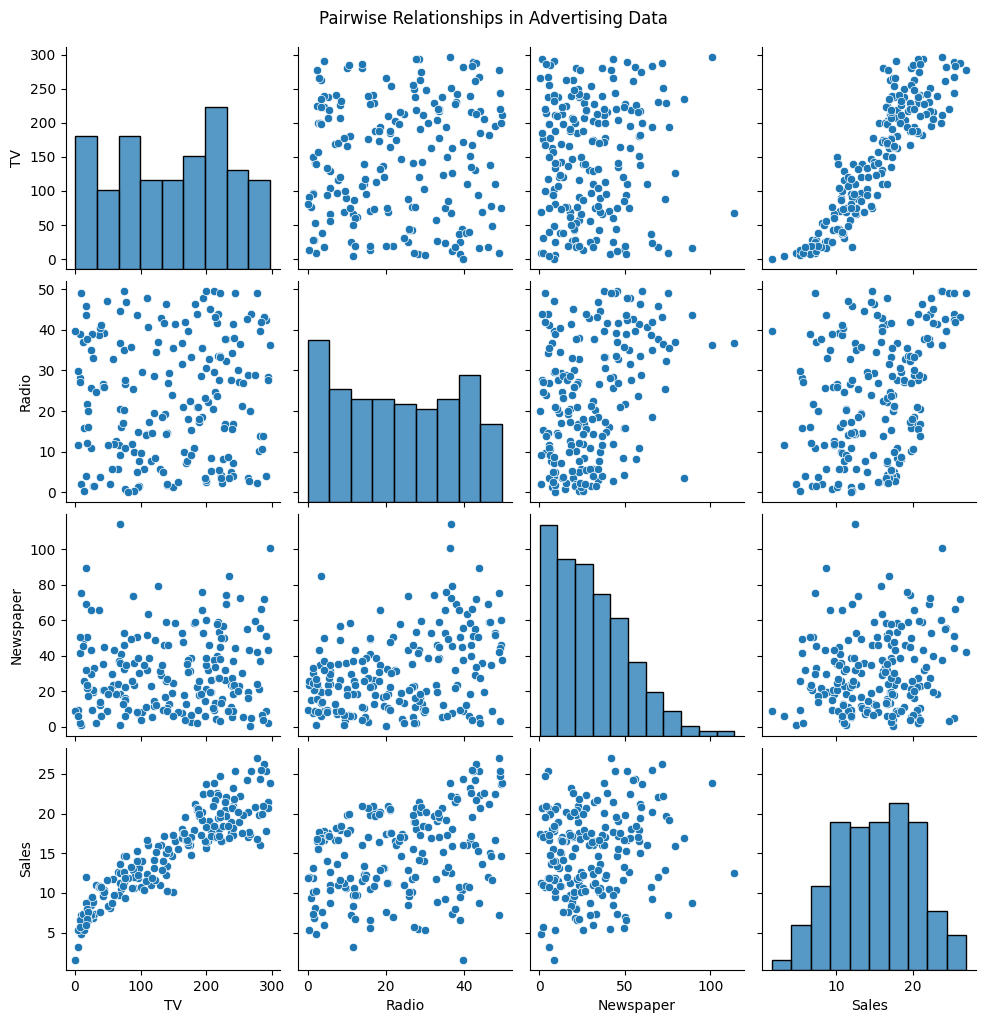

In [4]:
# Visualize correlations
sns.pairplot(df)
plt.suptitle("Pairwise Relationships in Advertising Data", y=1.02)
plt.show()

In [5]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nRMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 1.71
R² Score: 0.91


Predicted Future Sales: 16.01


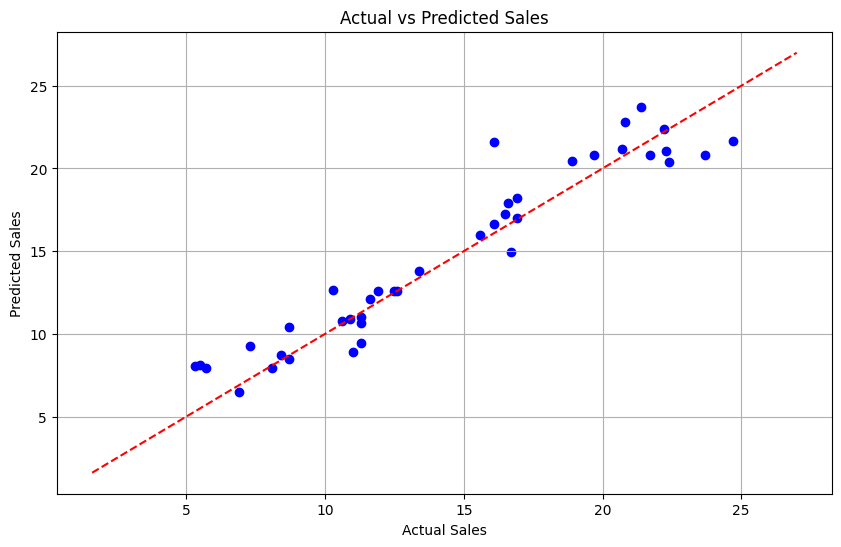

In [6]:
future_ads = pd.DataFrame([{
    'TV': 150,
    'Radio': 30,
    'Newspaper': 20
}])
future_pred = model.predict(future_ads)
print(f"Predicted Future Sales: {future_pred[0]:.2f}")

# Visualizing actual vs predicted sales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(True)
plt.show()